In [4]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [5]:
model = load_model("best_disease_model.keras")

print("Model Loaded Successfully!")

Model Loaded Successfully!


In [6]:
IMAGE_SIZE = 224
BATCH_SIZE = 32

DATASET_PATH = "New Plant Diseases Dataset(Augmented)"

In [7]:
valid_path = os.path.join(DATASET_PATH, "valid")

valid_datagen = ImageDataGenerator(
    rescale=1./255
)

validation_generator = valid_datagen.flow_from_directory(
    valid_path,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 17572 images belonging to 38 classes.


In [8]:
validation_generator.reset()

predictions = model.predict(
    validation_generator,
    verbose=1
)

predicted_classes = np.argmax(
    predictions,
    axis=1
)

true_classes = validation_generator.classes

class_names = list(
    validation_generator.class_indices.keys()
)

550/550 ━━━━━━━━━━━━━━━━━━━━ 141s 254ms/step


In [11]:
accuracy = accuracy_score(
    true_classes,
    predicted_classes
)

precision = precision_score(
    true_classes,
    predicted_classes,
    average="weighted"
)

recall = recall_score(
    true_classes,
    predicted_classes,
    average="weighted"
)

f1 = f1_score(
    true_classes,
    predicted_classes,
    average="weighted"
)

print("=" * 50)
print(f"Accuracy  : {accuracy*100:.2f}%")
print(f"Precision : {precision*100:.2f}%")
print(f"Recall    : {recall*100:.2f}%")
print(f"F1 Score  : {f1*100:.2f}%")
print("=" * 50)

Accuracy  : 95.27%
Precision : 95.31%
Recall    : 95.27%
F1 Score  : 95.24%


In [12]:
accuracy = accuracy_score(
    true_classes,
    predicted_classes
)

precision = precision_score(
    true_classes,
    predicted_classes,
    average="weighted"
)

recall = recall_score(
    true_classes,
    predicted_classes,
    average="weighted"
)

f1 = f1_score(
    true_classes,
    predicted_classes,
    average="weighted"
)

print("="*60)
print(f"Accuracy  : {accuracy*100:.2f}%")
print(f"Precision : {precision*100:.2f}%")
print(f"Recall    : {recall*100:.2f}%")
print(f"F1 Score  : {f1*100:.2f}%")
print("="*60)

Accuracy  : 95.27%
Precision : 95.31%
Recall    : 95.27%
F1 Score  : 95.24%


In [13]:
final_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

final_metrics.to_csv(
    "final_metrics.csv",
    index=False
)

final_metrics

,Metric,Value
0,Accuracy,0.952709
1,Precision,0.953090
2,Recall,0.952709
3,F1 Score,0.952383


In [14]:
report = classification_report(
    true_classes,
    predicted_classes,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df.head()

,precision,recall,f1-score,support
Apple___Apple_scab,0.973361,0.942460,0.957661,504.0
Apple___Black_rot,0.970356,0.987928,0.979063,497.0
Apple___Cedar_apple_rust,0.995381,0.979545,0.987400,440.0
Apple___healthy,0.982000,0.978088,0.980040,502.0
Blueberry___healthy,0.997727,0.966960,0.982103,454.0


In [15]:
report_df.to_csv(
    "classification_report.csv"
)

print("Classification Report Saved")

Classification Report Saved


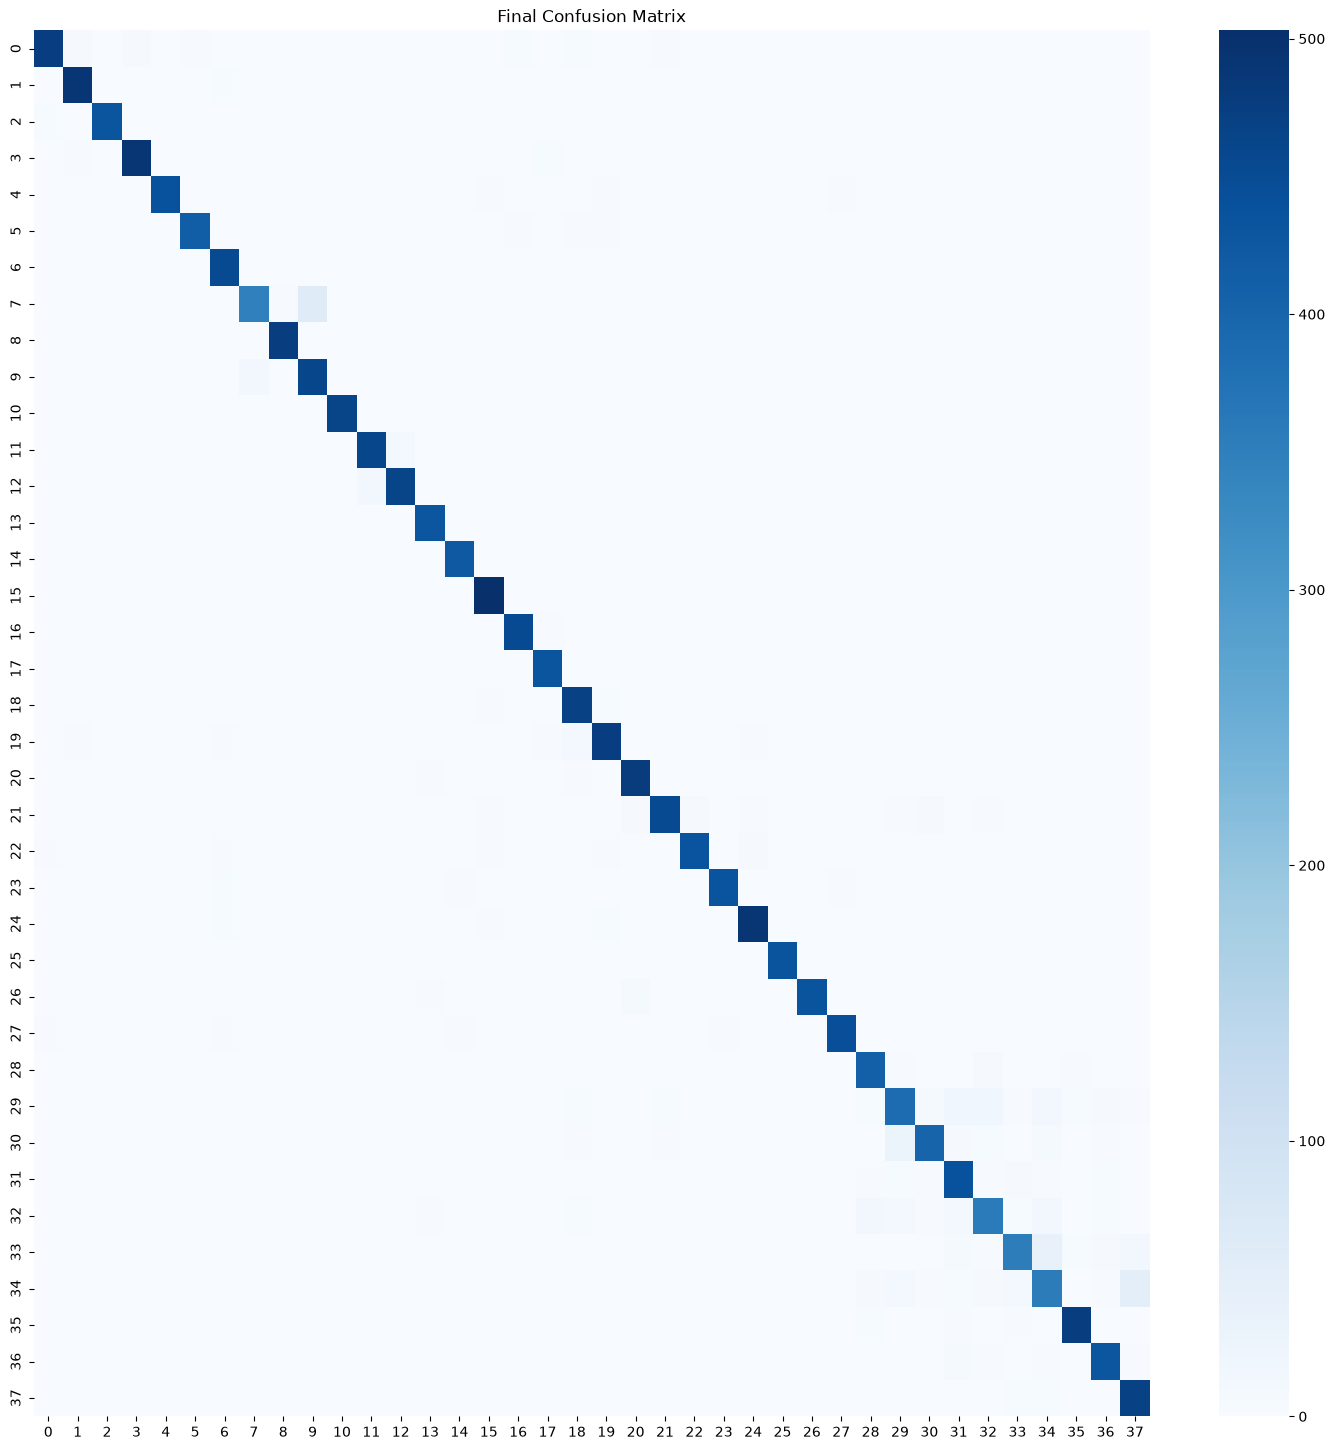

In [16]:
cm = confusion_matrix(
    true_classes,
    predicted_classes
)

plt.figure(figsize=(18,18))

sns.heatmap(
    cm,
    cmap="Blues",
    annot=False
)

plt.title("Final Confusion Matrix")

plt.savefig(
    "final_confusion_matrix.png",
    dpi=300
)

plt.show()

In [17]:
import json

In [18]:
with open("class_names.json", "r") as f:
    class_dict = json.load(f)

# Convert {"Tomato___Healthy":0,...}
# to a list indexed by class number

class_names = [None] * len(class_dict)

for name, index in class_dict.items():
    class_names[index] = name

print(class_names)

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Sp

Prediction : Tomato___Late_blight
Confidence : 43.95%


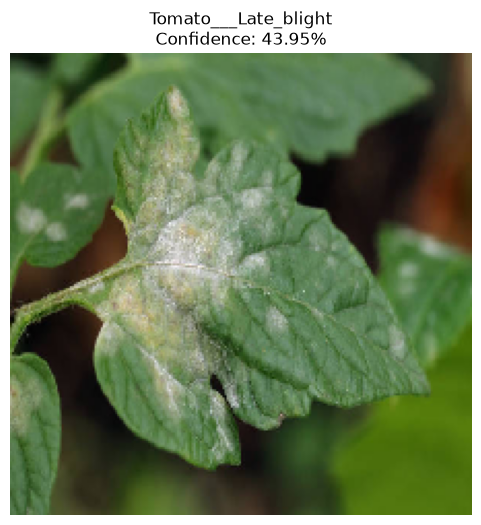

In [20]:
import json
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Load class names
with open("class_names.json", "r") as f:
    class_dict = json.load(f)

class_names = [None] * len(class_dict)

for name, index in class_dict.items():
    class_names[index] = name

# Load image
image_path = "test_images/leaf1.jpg"

img = image.load_img(
    image_path,
    target_size=(224,224)
)

img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array, verbose=0)

predicted = np.argmax(prediction)

confidence = np.max(prediction)

print("=" * 50)
print("Prediction :", class_names[predicted])
print(f"Confidence : {confidence*100:.2f}%")
print("=" * 50)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title(f"{class_names[predicted]}\nConfidence: {confidence*100:.2f}%")
plt.axis("off")
plt.show()